Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17207.49it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


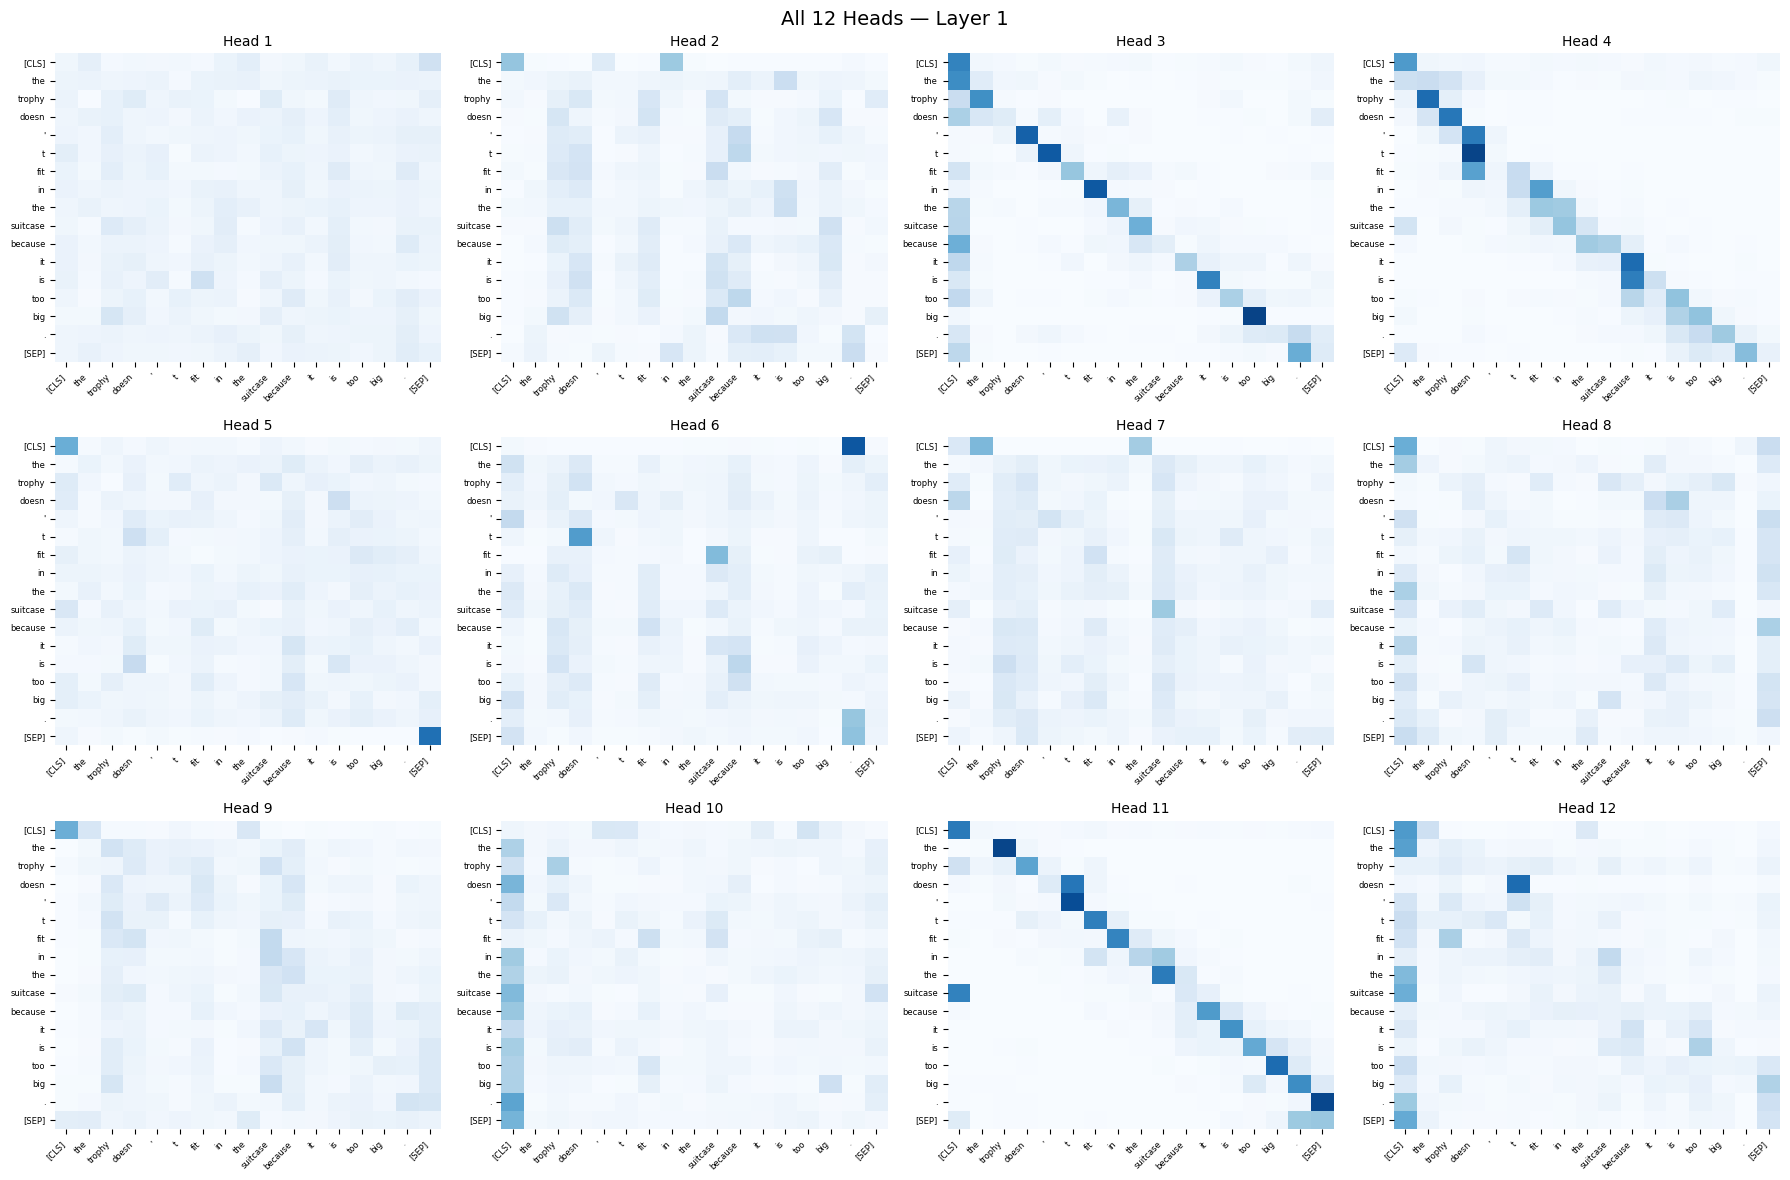

In [2]:
from transformers import BertTokenizer, BertModel
import torch
import matplotlib.pyplot as plt
import seaborn as sns

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
model.eval()

sentence = "The trophy doesn't fit in the suitcase because it is too big."
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

layer = 0
heads = outputs.attentions[layer][0]  # shape: (12, seq_len, seq_len)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for head in range(12):
    attn = heads[head].numpy()
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens,
                cmap="Blues", vmin=0, vmax=1,
                ax=axes[head], cbar=False)
    axes[head].set_title(f"Head {head+1}", fontsize=10)
    axes[head].tick_params(labelsize=6)
    axes[head].set_xticklabels(tokens, rotation=45, ha="right")

fig.suptitle(f"All 12 Heads — Layer {layer+1}", fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
from transformers import BertTokenizer, BertModel
from bertviz import head_view
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
model.eval()

sentence = "The trophy doesn't fit in the suitcase because it is too big."
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

# Opens an interactive visualization in Jupyter
# In a plain script, bertviz will emit an HTML string
head_view(outputs.attentions, tokens)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14377.91it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<IPython.core.display.Javascript object>

/home/hartpa/cs430/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 620.18it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task

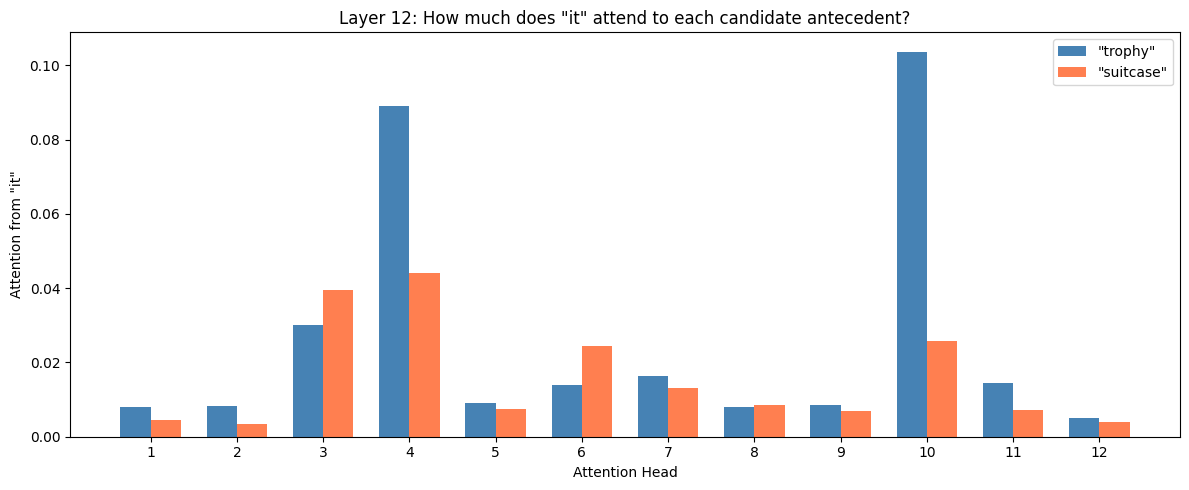

Saved: coreference_attention.png


In [1]:
from transformers import BertTokenizer, BertModel
import torch
import matplotlib.pyplot as plt
import numpy as np

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
model.eval()

sentence = "The trophy doesn't fit in the suitcase because it is too big."
inputs = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

it_idx       = tokens.index("it")
trophy_idx   = tokens.index("trophy")
suitcase_idx = tokens.index("suitcase")

layer = 11  # Layer 12 (0-indexed)
attn  = outputs.attentions[layer][0]  # shape: (heads, seq, seq)

trophy_attn   = attn[:, it_idx, trophy_idx].numpy()
suitcase_attn = attn[:, it_idx, suitcase_idx].numpy()

heads = np.arange(1, 13)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(heads - width/2, trophy_attn,   width, label='"trophy"',   color="steelblue")
ax.bar(heads + width/2, suitcase_attn, width, label='"suitcase"', color="coral")
ax.set_xlabel("Attention Head")
ax.set_ylabel('Attention from "it"')
ax.set_title('Layer 12: How much does "it" attend to each candidate antecedent?')
ax.set_xticks(heads)
ax.legend()
plt.tight_layout()
plt.savefig("coreference_attention.png", dpi=150)
plt.show()
print("Saved: coreference_attention.png")

Loading GloVe embeddings (this may take a minute)...


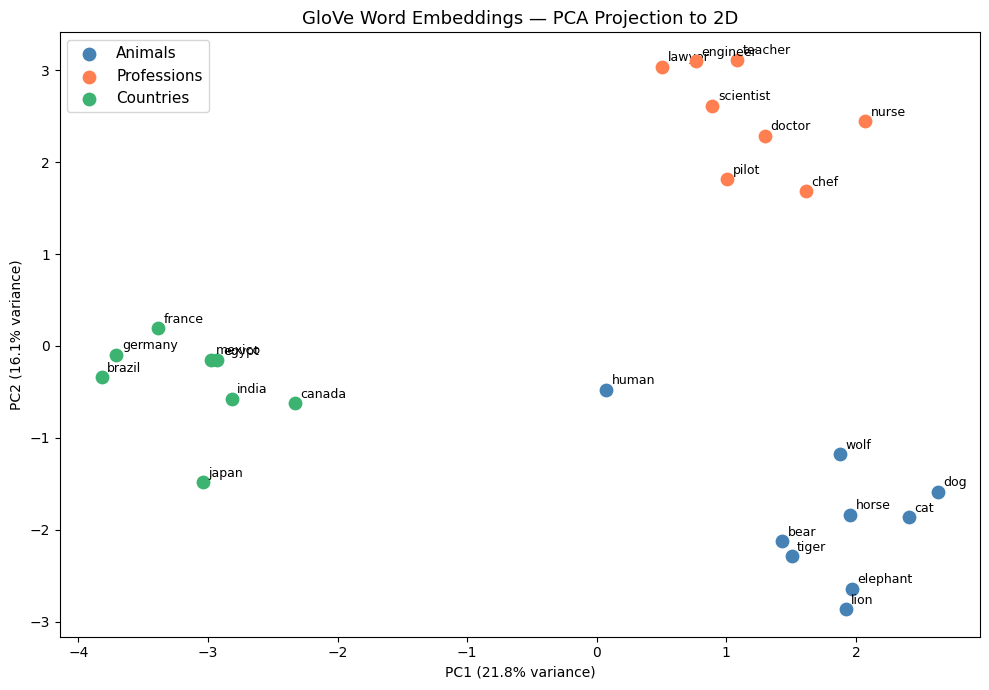

Saved: embeddings_pca.png


In [3]:
import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Loading GloVe embeddings (this may take a minute)...")
glove = api.load("glove-wiki-gigaword-100")

words = {
    "animals":     ["dog", "cat", "horse", "elephant", "lion", "tiger", "wolf", "bear", "human"],
    "professions": ["doctor", "lawyer", "teacher", "engineer", "nurse", "pilot", "chef", "scientist"],
    "countries":   ["france", "germany", "japan", "brazil", "egypt", "canada", "india", "mexico"],
}

all_words, all_labels, all_vecs = [], [], []
colors = {"animals": "steelblue", "professions": "coral", "countries": "mediumseagreen"}

for group, word_list in words.items():
    for w in word_list:
        if w in glove:
            all_words.append(w)
            all_labels.append(group)
            all_vecs.append(glove[w])

vectors = np.array(all_vecs)
pca     = PCA(n_components=2)
coords  = pca.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(10, 7))
for i, (word, label) in enumerate(zip(all_words, all_labels)):
    ax.scatter(*coords[i], color=colors[label], s=80, zorder=3)
    ax.annotate(word, coords[i], fontsize=9, xytext=(4, 4), textcoords="offset points")

for group, color in colors.items():
    ax.scatter([], [], color=color, label=group.capitalize(), s=80)
ax.legend(fontsize=11)
ax.set_title("GloVe Word Embeddings — PCA Projection to 2D", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.savefig("embeddings_pca.png", dpi=150)
plt.show()
print("Saved: embeddings_pca.png")

In [4]:
import gensim.downloader as api
import numpy as np

glove = api.load("glove-wiki-gigaword-100")

# ── Analogy Arithmetic ───────────────────────────────────────────────
def analogy(a, b, c, topn=5):
    """Find d such that a:b :: c:d"""
    try:
        return glove.most_similar(positive=[b, c], negative=[a], topn=topn)
    except KeyError as e:
        return f"Word not found: {e}"

print("=" * 50)
print("ANALOGY COMPLETION  (a : b :: c : ?)")
print("=" * 50)
probes = [
    ("man",   "king",   "woman"),
    ("paris", "france", "berlin"),
    ("walk",  "walked", "run"),
]
for a, b, c in probes:
    results = analogy(a, b, c)
    top = results[0][0] if isinstance(results, list) else results
    print(f"  {a}:{b} :: {c}:? → top answer: '{top}'")
    if isinstance(results, list):
        print(f"    Full top-5: {[r[0] for r in results]}")

# ── Bias Probe ───────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("GENDER–PROFESSION BIAS PROBE")
print("Cosine similarity to 'man' vs 'woman'")
print("=" * 50)

professions = ["doctor", "nurse", "engineer", "teacher", "ceo", "secretary", "pilot", "librarian"]

def cosine(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

man_vec   = glove["man"]
woman_vec = glove["woman"]

print(f"  {'Profession':>12}  {'sim(man)':>10}  {'sim(woman)':>12}  {'Closer to':>10}")
for prof in professions:
    if prof in glove:
        sm = cosine(glove[prof], man_vec)
        sw = cosine(glove[prof], woman_vec)
        print(f"  {prof:>12}  {sm:>10.4f}  {sw:>12.4f}  {'man' if sm > sw else 'woman':>10}")

ANALOGY COMPLETION  (a : b :: c : ?)
  man:king :: woman:? → top answer: 'queen'
    Full top-5: ['queen', 'monarch', 'throne', 'daughter', 'princess']
  paris:france :: berlin:? → top answer: 'germany'
    Full top-5: ['germany', 'austria', 'poland', 'denmark', 'german']
  walk:walked :: run:? → top answer: 'went'
    Full top-5: ['went', 'drove', 'ran', 'came', 'last']

GENDER–PROFESSION BIAS PROBE
Cosine similarity to 'man' vs 'woman'
    Profession    sim(man)    sim(woman)   Closer to
        doctor      0.6092        0.6333       woman
         nurse      0.4562        0.6139       woman
      engineer      0.4300        0.3340         man
       teacher      0.5256        0.5791       woman
           ceo      0.3049        0.2004         man
     secretary      0.3502        0.2875         man
         pilot      0.4611        0.4094         man
     librarian      0.2263        0.3365       woman


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer  = AutoTokenizer.from_pretrained(model_name)
model      = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

sentence = "The film was surprisingly brilliant but the ending was a disaster."
inputs   = tokenizer(sentence, return_tensors="pt")
tokens   = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Enable gradient tracking on embeddings
embeddings = model.distilbert.embeddings(inputs["input_ids"])
embeddings.retain_grad()

outputs   = model(inputs_embeds=embeddings, attention_mask=inputs["attention_mask"])
pos_score = outputs.logits[0, 1]  # POSITIVE class logit
pos_score.backward()

# Saliency: L2 norm of (gradient × embedding), then normalize
grad     = embeddings.grad[0]
saliency = (grad * embeddings[0].detach()).norm(dim=-1).detach().numpy()
saliency = saliency / saliency.max()

print(f"\nSentence : {sentence}")
print(f"Logits   : {outputs.logits.softmax(-1)[0].tolist()}\n")
print(f"{'Token':>15}  {'Saliency':>8}")
print("-" * 30)
for tok, sal in zip(tokens, saliency):
    bar = "█" * int(sal * 20)
    print(f"{tok:>15}  {sal:>8.4f}  {bar}")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 15603.92it/s]


Sentence : The film was surprisingly brilliant but the ending was a disaster.
Logits   : [0.9992849230766296, 0.0007150578894652426]

          Token  Saliency
------------------------------
          [CLS]    0.3781  ███████
            the    0.1675  ███
           film    0.3610  ███████
            was    0.2092  ████
   surprisingly    0.3423  ██████
      brilliant    0.4662  █████████
            but    0.3512  ███████
            the    0.3054  ██████
         ending    0.2750  █████
            was    0.2795  █████
              a    0.3031  ██████
       disaster    1.0000  ████████████████████
              .    0.4234  ████████
          [SEP]    0.2244  ████


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer  = AutoTokenizer.from_pretrained(model_name)
model      = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

sentence = "The film was surprisingly brilliant but the ending was a disaster."

def predict(text):
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        probs = model(**inputs).logits.softmax(-1)[0]
    label = "POSITIVE" if probs[1] > probs[0] else "NEGATIVE"
    return label, max(probs).item()

def mask_word(text, word):
    return text.replace(word, "[MASK]", 1)

base_label, base_conf = predict(sentence)
print(f"Original  : '{sentence}'")
print(f"Prediction: {base_label} ({base_conf:.4f})\n")

targets = [
    ("brilliant",   "high saliency"),
    ("disaster",    "high saliency"),
    ("was",         "low saliency (expected)"),
    ("surprisingly","medium saliency"),
]

print(f"{'Masked':>15}  {'Label':>10}  {'Conf':>8}  {'Δ Conf':>8}  Note")
print("-" * 65)
for word, note in targets:
    lbl, conf = predict(mask_word(sentence, word))
    print(f"{word:>15}  {lbl:>10}  {conf:>8.4f}  {conf - base_conf:>+8.4f}  {note}")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11876.06it/s]

Original  : 'The film was surprisingly brilliant but the ending was a disaster.'
Prediction: NEGATIVE (0.9994)

         Masked       Label      Conf    Δ Conf  Note
-----------------------------------------------------------------
      brilliant    NEGATIVE    0.9994   +0.0001  high saliency
       disaster    POSITIVE    0.9888   -0.0105  high saliency
            was    NEGATIVE    0.9989   -0.0005  low saliency (expected)
   surprisingly    NEGATIVE    0.9991   -0.0002  medium saliency


In [5]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis",
                      model="distilbert-base-uncased-finetuned-sst-2-english")

# (original, counterfactual, type_of_change)
pairs = [
    ("The food was excellent.",            "The food was terrible.",             "excellent→terrible"),
    ("The food was excellent.",            "The food was not excellent.",         "add 'not'"),
    ("I really loved this experience.",    "I really hated this experience.",     "loved→hated"),
    ("The movie was surprisingly good.",   "The movie was surprisingly bad.",     "good→bad"),
    ("I can't say I didn't enjoy it.",     "I can't say I enjoyed it.",           "remove 'didn't'"),
    ("She gave a brilliant performance.",  "She gave a mediocre performance.",    "brilliant→mediocre"),
    ("She gave a brilliant performance.",  "She gave a performance.",             "remove adjective"),
    ("It wasn't the worst film I've seen.","It was the worst film I've seen.",    "wasn't→was"),
    ("A masterpiece of modern cinema.",    "A disappointment of modern cinema.",  "masterpiece→disappointment"),
    ("The ending left me feeling hopeful.","The ending left me feeling empty.",   "hopeful→empty"),
]

print(f"{'Original':>42}  {'Edit':>24}  {'Orig':>8}  {'CF':>8}  {'ΔConf':>7}")
print("-" * 100)

for original, cf, edit_type in pairs:
    r_o  = classifier(original)[0]
    r_cf = classifier(cf)[0]
    delta = r_cf["score"] - r_o["score"]
    flip  = " ←FLIP" if r_o["label"] != r_cf["label"] else ""
    print(f"  {original[:40]:>40}  {edit_type:>24}  "
          f"{r_o['label']:>8}  {r_cf['label']:>8}  {delta:>+7.3f}{flip}")

print("\nNegation cases — detailed:")
for original, cf, edit_type in pairs:
    if any(w in edit_type for w in ["not", "didn't", "wasn't"]):
        r_o  = classifier(original)[0]
        r_cf = classifier(cf)[0]
        print(f"\n  Edit: {edit_type}")
        print(f"    Original      : \"{original}\" → {r_o['label']} ({r_o['score']:.3f})")
        print(f"    Counterfactual: \"{cf}\" → {r_cf['label']} ({r_cf['score']:.3f})")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11972.21it/s]


                                  Original                      Edit      Orig        CF    ΔConf
----------------------------------------------------------------------------------------------------
                   The food was excellent.        excellent→terrible  POSITIVE  NEGATIVE   -0.001 ←FLIP
                   The food was excellent.                 add 'not'  POSITIVE  NEGATIVE   -0.000 ←FLIP
           I really loved this experience.               loved→hated  POSITIVE  NEGATIVE   -0.001 ←FLIP
          The movie was surprisingly good.                  good→bad  POSITIVE  NEGATIVE   -0.000 ←FLIP
            I can't say I didn't enjoy it.           remove 'didn't'  NEGATIVE  NEGATIVE   -0.390
         She gave a brilliant performance.        brilliant→mediocre  POSITIVE  NEGATIVE   -0.001 ←FLIP
         She gave a brilliant performance.          remove adjective  POSITIVE  POSITIVE   -0.000
       It wasn't the worst film I've seen.                wasn't→was  NEGATIVE  NEGAT